Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

---
# Metody jądrowe
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, matthews_corrcoef, ConfusionMatrixDisplay

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.2'

# Przykład - [Drug Consumption (Quantified)](https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified)

- W tym ćwiczeniu dokonamy próby klasyfikacji, jak często dana osoba sięga po określony typ używek (alkohol, narkotyki) na podstawie jego zanonimizowanych danych osobowościowych
- Tego typu analizy są niezwykle istotne do określania grup ryzyka i podejmowania m.in. działań prewencyjnych

## Załadowanie danych

- Dane kategoryczne są skwantyfikowane za pomocą nieliniowej CatPCA (*nonlinear Categorical Principal Component Analysis*) - zob. [artykuł](https://arxiv.org/pdf/1506.06297)
- Jest to alternatywa do *one-hot encoding*, która pozwala na zmniejszenie liczby zmiennych niezależnych (wyjaśniających)


In [3]:
drugs = fetch_ucirepo(id=373) 
X = drugs.data.features 
y_all = drugs.data.targets
# Przewidujemy doświadczenia z grzybami halucynogennymi
y = y_all.mushrooms

In [4]:
X.shape, len(y)

((1885, 12), 1885)

## Wstępne przetwarzanie danych

### Brakujące dane

In [5]:
X[pd.isna(X).any(axis=1)]

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss


### Usunięcie danych osób mających potencjalnie zaburzone wyniki (*over-claimers*)

- Kwerenda została skonstruowana tak, że zapytano badanych o ich doświadczenia z nieistniejącą używką o nazwie semeron (kolumna `Semer` w danych)
- Ponieważ nie jest to prawdziwy narkotyk, zakłada się, że osoby, które twierdziły, że zażywały semeron, mogły celowo zmyślać. Dla pewności, usuniemy takie dane (tym bardziej, że nie ma ich wiele)

In [6]:
y_all['semer'].value_counts() 

semer
CL0    1877
CL2       3
CL3       2
CL1       2
CL4       1
Name: count, dtype: int64

In [7]:
idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

### Zmienne katagoryczne

#### Rzadkie kategorie

Usuwamy najrzadszą katagorię

In [8]:
y.value_counts()

mushrooms
CL0    982
CL3    272
CL2    259
CL1    208
CL4    114
CL5     39
CL6      3
Name: count, dtype: int64

In [9]:
idx_to_drop = y[y == 'CL6'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

#### Kodowanie katagorii

- Podobnie jak w poprzednim ćwiczeniu, używamy `LabelEncoder`
- **Uwaga:** pamiętajmy, że niektóre API pozwalają na kategorie tekstowe i wtedy użycie enkodera nie jest wymagane

In [10]:
label_encoder = LabelEncoder()

In [11]:
y_trans = label_encoder.fit_transform(y.values)

## Klasyfikator SVM

### Podział danych na zbiór treningowy i testowy oraz trening modelu
- Tym razem używamy walidacji krzyżowej
- Jako miary dokładności, używamy `f1-score` oraz współczynnika korelacji Matthewsa MCC (`matthews_corrcoef`)
- Zaczynamy od liniowej maszyny wektorów nośnych

In [12]:
# Zbiór treningowy stanowi 80% całego zbioru (5 podziałów)
rkf = KFold(n_splits=5)
for i, (idx_train, idx_test) in enumerate(rkf.split(X, y_trans)):
    # Wybór modelu
    svc = SVC(kernel='linear', max_iter=10_000, C=1, random_state=0)
    # Podział zbioru na dane treningowe i testowe
    X_train = X.iloc[idx_train]
    y_train = y_trans[idx_train]
    X_test = X.iloc[idx_test]
    y_test = y_trans[idx_test]
    # Trening modelu
    svc.fit(X_train, y_train)
    y_pred_train = svc.predict(X_train)
    y_pred_test  = svc.predict(X_test)
    # Miary dokładności
    f1_train = f1_score(y_train, y_pred_train, average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    mcc_train = matthews_corrcoef(y_train, y_pred_train)
    mcc_test = matthews_corrcoef(y_test, y_pred_test)
    print(f"{i+1} iteracja, train: ({f1_train:.2f}, {mcc_train:.2f}), test: ({f1_test:.2f}, {mcc_test:.2f})")

1 iteracja, train: (0.19, 0.22), test: (0.21, 0.04)
2 iteracja, train: (0.20, 0.25), test: (0.16, 0.12)
3 iteracja, train: (0.20, 0.24), test: (0.15, 0.11)
4 iteracja, train: (0.19, 0.20), test: (0.19, 0.22)
5 iteracja, train: (0.19, 0.23), test: (0.21, 0.28)


#### Macierz pomyłek (dla ostatniego podziału)

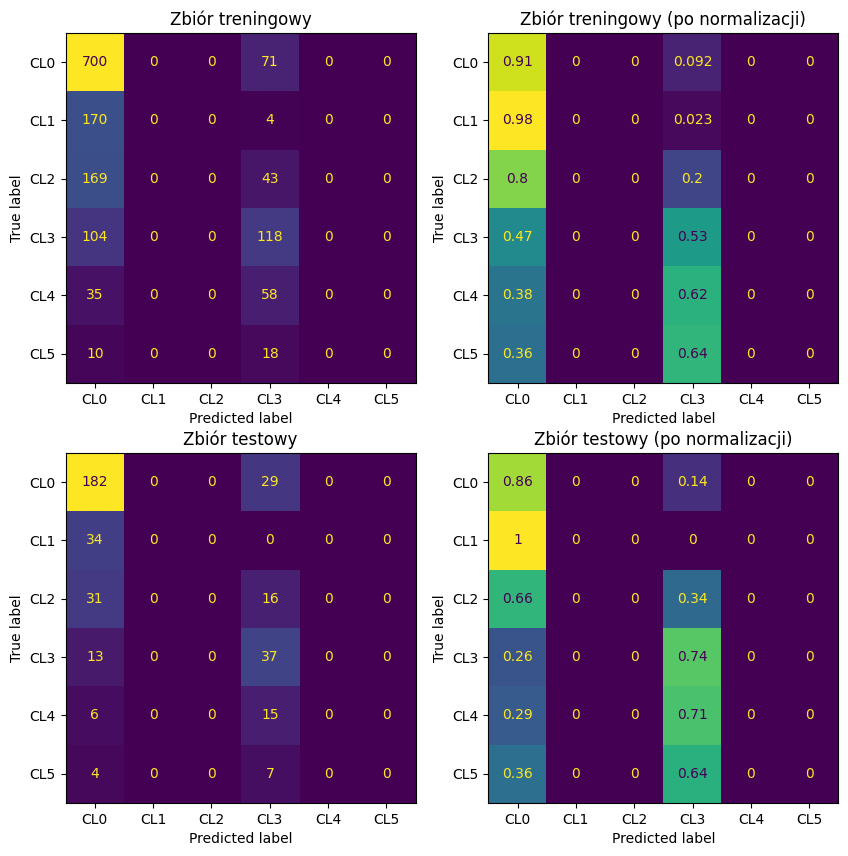

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
kwargs = {'colorbar': None, 'display_labels': label_encoder.classes_}
labels = ['Zbiór treningowy', 'Zbiór testowy']
for i, (y1, y2) in enumerate(zip([y_train, y_test], [y_pred_train, y_pred_test])):
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 0], **kwargs)
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 1], normalize="true", **kwargs)
    ax[i, 0].set_title(f"{labels[i]}")
    ax[i, 1].set_title(f"{labels[i]} (po normalizacji)")
plt.show()

Wyniki są dalekie od oczekiwań!